# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [ ]:
# 3 different models

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Employee_productivity.csv ')

#years at company vs Productivity Score
Years_df = df['YearsAtCompany'].corr(df['ProductivityScore'])
r2_years = Years_df ** 2

#Hours Worked vs Productivity Score
Hours_df = df['HoursWorked'].corr(df['ProductivityScore'])
r2_Hours = Hours_df ** 2

#Focus VS Productivity Score
Focus_df = df['FocusScore'].corr(df['ProductivityScore'])
r2_Focus = Focus_df ** 2 



In [ ]:
print("R^2 for Years at Company vs Productivity Score:", r2_years)
print("R^2 for Hours Worked vs Productivity Score:", r2_Hours)
print("R^2 for Focus Score vs Productivity Score:", r2_Focus)

R^2 for Years at Company vs Productivity Score: 0.0004115291938967004
R^2 for Hours Worked vs Productivity Score: 0.002599935002265336
R^2 for Focus Score vs Productivity Score: 0.6776960770307455


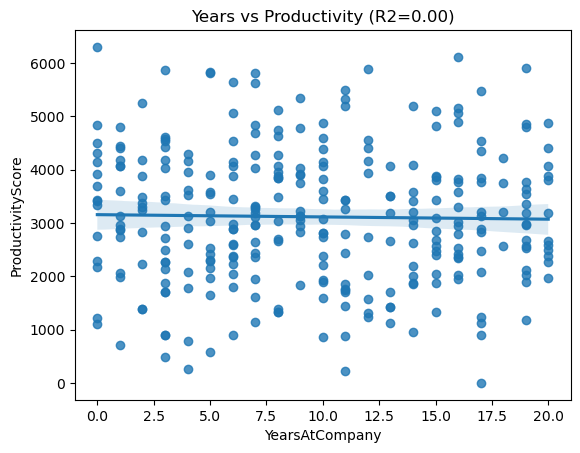

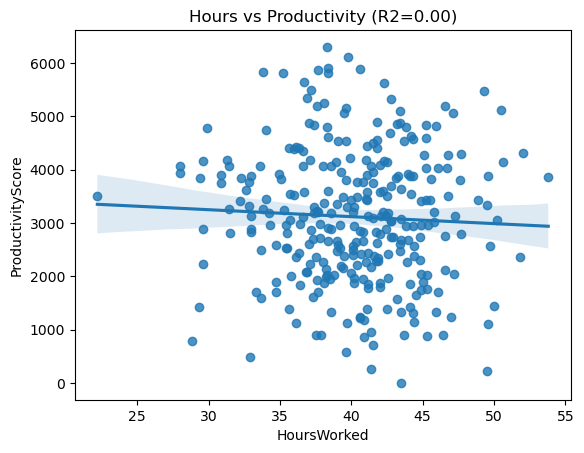

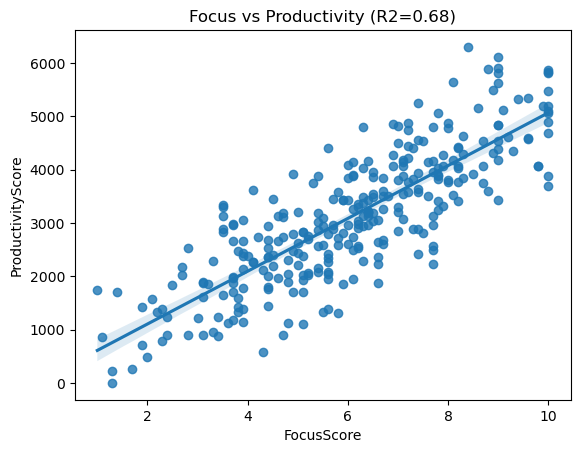

In [19]:

plt.figure()
sns.regplot(data=df, x='YearsAtCompany', y='ProductivityScore')
plt.title(f'Years vs Productivity (R2={r2_years:.2f})')
plt.show()

plt.figure()
sns.regplot(data=df, x='HoursWorked', y='ProductivityScore')
plt.title(f'Hours vs Productivity (R2={r2_Hours:.2f})')
plt.show()


plt.figure()
sns.regplot(data=df, x='FocusScore', y='ProductivityScore')
plt.title(f'Focus vs Productivity (R2={r2_Focus:.2f})')
plt.show()

In [21]:
corr_meetings = df['TeamMeetingsPerWeek'].corr(df['ProductivityScore'])
r2_meetings = corr_meetings ** 2
print("R-squared for Meetings:", r2_meetings)

R-squared for Meetings: 0.054244651231489256


In [20]:
print(df.groupby('DeskLocation')['ProductivityScore'].mean())
print(df.groupby('Department')['ProductivityScore'].mean())

DeskLocation
Open Plan         2863.193689
Private Office    3226.829813
Remote            3267.437556
Name: ProductivityScore, dtype: float64
Department
Engineering    3163.429200
HR             3130.056375
Marketing      3072.281389
Sales          3087.440548
Name: ProductivityScore, dtype: float64


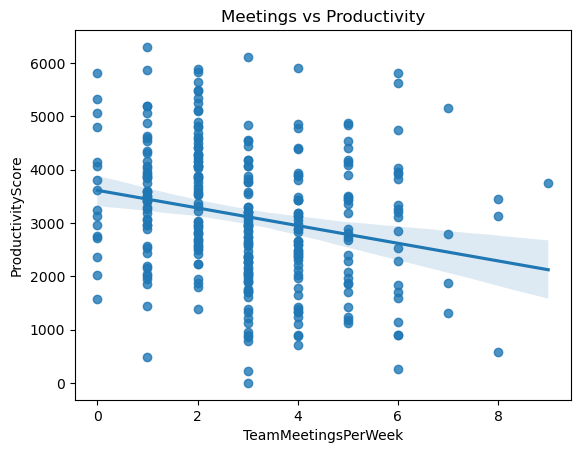

In [22]:
plt.figure()
sns.regplot(data=df, x='TeamMeetingsPerWeek', y='ProductivityScore')
plt.title('Meetings vs Productivity')
plt.show()

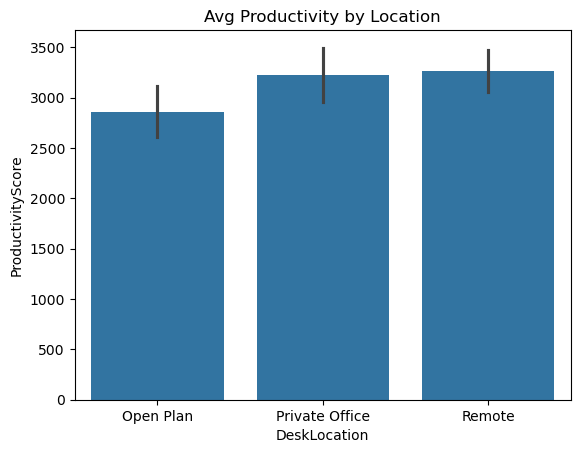

In [23]:
plt.figure()
sns.barplot(data=df, x='DeskLocation', y='ProductivityScore', )
plt.title('Avg Productivity by Location')
plt.show()


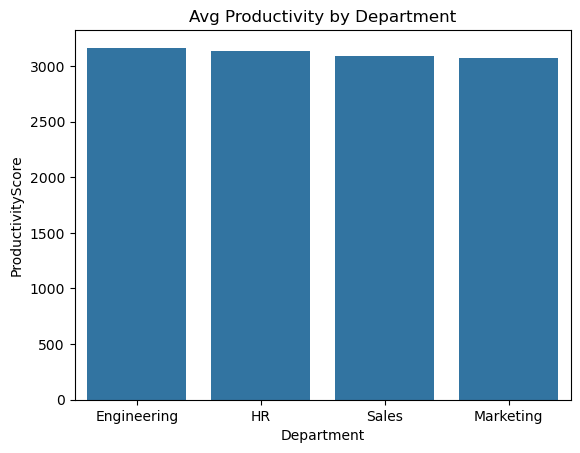

In [24]:
plt.figure()
sns.barplot(data=df, x='Department', y='ProductivityScore', errorbar=None)
plt.title('Avg Productivity by Department')
plt.show()

Within the Graphs we can see a whole load of data being compared and contrast. The most logical evidence that shows any form of corrolation is the Focus Score. The average productivity by department only show cases that it has no descrpencies amonst each departments Productivity levels. While another graph shows that Working from home has the highest amount of productivity that the other two options. But to the point that its comparable to having a private office. Teams that have the highest Focus Scores, on average. Have higher productivity.